In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/zomato.csv",encoding="latin-1")
print(f"Origin Shape: {df.shape}")
print(df.columns.tolist())

Origin Shape: (51717, 17)
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [3]:
drop_cols=['url','address','phone','dish_liked','reviews_list','menu_item']
df.drop(columns=drop_cols,inplace=True)
print(f"After dropping useless columns: {df.shape}")
print(df.columns.tolist())

After dropping useless columns: (51717, 11)
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']


In [4]:
def clean_rate(value):
    if pd.isnull(value):
        return np.nan
    value=str(value).strip()
    if value in["NEW","-","nan"]:
        return np.nan
    value=value.replace(" ","")
    value=value.replace("/5","")
    try:
        return float(value)
    except:
        return np.nan

df['rate']=df['rate'].apply(clean_rate)
print(f"Rate nulls after cleaning: {df['rate'].isnull().sum()}")
print(f"Rate range from {df['rate'].min()} to {df['rate'].max()}")
print(df['rate'].describe)

Rate nulls after cleaning: 10052
Rate range from 1.8 to 4.9
<bound method NDFrame.describe of 0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64>


In [5]:
df['approx_cost(for two people)']=(df['approx_cost(for two people)'].astype(str).str.replace(',','',regex=False).str.strip())
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')
df.rename(columns={'approx_cost(for two people)':'cost_for_two'},inplace=True)
print(df['cost_for_two'].describe)

<bound method NDFrame.describe of 0         800.0
1         800.0
2         800.0
3         300.0
4         600.0
          ...  
51712    1500.0
51713     600.0
51714    2000.0
51715    2500.0
51716    1500.0
Name: cost_for_two, Length: 51717, dtype: float64>


In [6]:
print(df['online_order'].value_counts())
print(df['book_table'].value_counts())

df['online_order']=df['online_order'].map({'Yes':1,'No':0})
df['book_table']=df['book_table'].map({'Yes':1,'No':0})

online_order
Yes    30444
No     21273
Name: count, dtype: int64
book_table
No     45268
Yes     6449
Name: count, dtype: int64


In [7]:
print("Nulls before final drop:")
print(df.isnull().sum())

df.dropna(subset=['location','rest_type','cuisines','cost_for_two'],inplace=True)
print(f"\n Final shape: {df.shape}")
print(f"\n Nulls in rate remaining: {df.isnull().sum()}")

Nulls before final drop:
name                   0
online_order           0
book_table             0
rate               10052
votes                  0
location              21
rest_type            227
cuisines              45
cost_for_two         346
listed_in(type)        0
listed_in(city)        0
dtype: int64

 Final shape: (51148, 11)

 Nulls in rate remaining: name                  0
online_order          0
book_table            0
rate               9885
votes                 0
location              0
rest_type             0
cuisines              0
cost_for_two          0
listed_in(type)       0
listed_in(city)       0
dtype: int64


In [8]:
# See why duplicates exist
print(df[df.duplicated(subset=['name', 'location'], keep=False)]
      [['name', 'location', 'listed_in(type)', 'rate', 'votes']]
      .sort_values(['name', 'location'])
      .head(12))

                name         location listed_in(type)  rate  votes
4321    #FeelTheROLL        Bellandur        Delivery   3.4      7
49511   #FeelTheROLL        Bellandur        Delivery   3.4      7
10182     #L-81 Cafe              HSR        Delivery   3.9     48
11096     #L-81 Cafe              HSR        Dine-out   3.9     48
16606     #L-81 Cafe              HSR        Delivery   3.9     48
17166     #L-81 Cafe              HSR        Dine-out   3.9     48
28099     #L-81 Cafe              HSR        Delivery   3.9     48
29004     #L-81 Cafe              HSR        Dine-out   3.9     48
30833     #L-81 Cafe              HSR        Delivery   3.9     48
33627     #L-81 Cafe              HSR        Delivery   3.9     48
36386     #L-81 Cafe              HSR        Delivery   3.9     48
13380  #Vibes Restro  Electronic City          Buffet   NaN      0


In [9]:

df = df.sort_values('votes', ascending=False)
df = df.drop_duplicates(subset=['name', 'location'], keep='first')
df = df.reset_index(drop=True)

print(f"Final shape after dedup: {df.shape}")  # Should be ~8723

Final shape after dedup: (12037, 11)


In [10]:
print("=== Final Cleaned DataFrame ===\n")
print(f"Shape: {df.shape}\n")
print(f"Datatypes: \n{df.dtypes}\n")
print(f"Null Counts: \n{df.isnull().sum()}\n")
print("Sample: ")
df.head()

=== Final Cleaned DataFrame ===

Shape: (12037, 11)

Datatypes: 
name                object
online_order         int64
book_table           int64
rate               float64
votes                int64
location            object
rest_type           object
cuisines            object
cost_for_two       float64
listed_in(type)     object
listed_in(city)     object
dtype: object

Null Counts: 
name                  0
online_order          0
book_table            0
rate               2881
votes                 0
location              0
rest_type             0
cuisines              0
cost_for_two          0
listed_in(type)       0
listed_in(city)       0
dtype: int64

Sample: 


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,listed_in(type),listed_in(city)
0,Byg Brewski Brewing Company,1,1,4.9,16832,Sarjapur Road,Microbrewery,"Continental, North Indian, Italian, South Indi...",1600.0,Dine-out,Sarjapur Road
1,Toit,0,0,4.7,14956,Indiranagar,Microbrewery,"Italian, American, Pizza",1500.0,Dine-out,Indiranagar
2,Truffles,0,0,4.7,14726,Koramangala 5th Block,"Cafe, Casual Dining","Cafe, American, Burger, Steak",900.0,Dine-out,Koramangala 7th Block
3,AB's - Absolute Barbecues,0,1,4.8,12121,Marathahalli,Casual Dining,"European, Mediterranean, North Indian, BBQ",1600.0,Dine-out,Marathahalli
4,The Black Pearl,0,1,4.7,10550,Koramangala 5th Block,"Casual Dining, Bar","North Indian, European, Mediterranean",1400.0,Pubs and bars,Koramangala 7th Block


In [11]:
df.to_csv("../data/zomato_cleaned.csv",index=False)
print("Saved: Cleaned zomato_cleaned.csv") 

Saved: Cleaned zomato_cleaned.csv


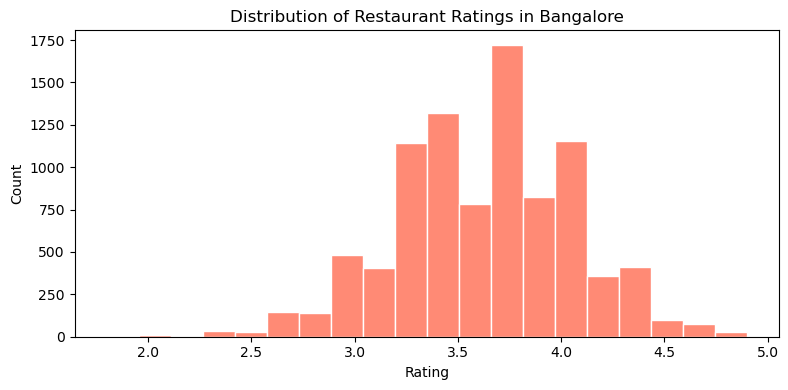

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['rate'].dropna(),bins=20,color='tomato',edgecolor='white')
plt.title("Distribution of Restaurant Ratings in Bangalore")
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../visuals/rating_distribution.png',dpi=150)
plt.show()